# Activity 1: Visualizing LieBN

<p align="center">
  <a href="https://github.com/GitZH-Chen/MLSS-RDL-Tutorial"><img src="https://raw.githubusercontent.com/GitZH-Chen/MLSS-RDL-Tutorial/9bcd21ec89b2eec53fb0d43c94943b0fa6e3c6e6/assets/github-repository-qr.png" width="180" alt="QR code for the MLSS RDL tutorial repository"></a>
</p>
<p align="center"><a href="https://github.com/GitZH-Chen/MLSS-RDL-Tutorial">https://github.com/GitZH-Chen/MLSS-RDL-Tutorial</a></p>

Tasks:

1. apply LieBN-AIM to $\operatorname{SPD}(2)$;
2. change its scaling parameter while keeping the input batch fixed;
3. compare LieBN across SPD, rotation, and correlation manifolds.

## Mathematical preliminaries

A **Lie group** $(ℳ,\odot)$ is both a smooth manifold and a group. Its multiplication and inverse maps,

$$
m(x,y)=x\odot y,\qquad i(x)=x_{\odot}^{-1}.
$$

are smooth. Left and right translations are

$$
L_x(y)=x\odot y,\qquad R_x(y)=y\odot x.
$$

A Riemannian metric $g$ is **left-invariant** if

$$
g_y(U,V)=g_{L_x(y)}\left((L_x)_{*,y}U,(L_x)_{*,y}V\right).
$$

and **right-invariant** analogously using $R_x$. The corresponding translations are isometries, which allows LieBN to center and bias a batch through group translations.

For samples $\{P_i\}_{i=1}^{N}$, the Fréchet mean and variance are

$$
M=\underset{P\in ℳ}{\operatorname{argmin}}\frac{1}{N}\sum_{i=1}^{N}d^2(P_i,P),\qquad v^2=\frac{1}{N}\sum_{i=1}^{N}d^2(P_i,M).
$$

## References

- **Extended version.** Ziheng Chen, Yue Song, Rui Wang, Xiao-Jun Wu, and Nicu Sebe. **LieBN: Batch Normalization over Lie Groups.** arXiv:2607.08783, 2026. [Paper](https://arxiv.org/abs/2607.08783) · [Code](https://github.com/GitZH-Chen/LieBN)
- **Conference version.** Ziheng Chen, Yue Song, Yunmei Liu, and Nicu Sebe. **A Lie Group Approach to Riemannian Batch Normalization.** ICLR 2024. [Paper](https://openreview.net/forum?id=okYdj8Ysru)


## Setup


In [54]:
%pip -q install geoopt==0.5.1


In [ ]:
from pathlib import Path
import importlib.util
import subprocess
import sys

dependency_root = Path("/content/mlss_tutorial_dependencies")
dependency_root.mkdir(parents=True, exist_ok=True)

repositories = {
    "LieBN": (
        "https://github.com/GitZH-Chen/LieBN.git",
        "ff2e6a5276360ab862b38e827f6640233cf665d2",
    ),
}

def checkout_repository(name, url, commit):
    target = dependency_root / name
    if not target.exists():
        subprocess.run(["git", "clone", "--quiet", url, str(target)], check=True)
    subprocess.run(
        ["git", "-C", str(target), "checkout", "--quiet", commit],
        check=True,
    )
    return target

liebn_path = checkout_repository("LieBN", *repositories["LieBN"])

extra_paths = [str(liebn_path)]
if importlib.util.find_spec("pytorch3d") is None:
    pytorch3d_path = checkout_repository(
        "PyTorch3D",
        "https://github.com/facebookresearch/pytorch3d.git",
        "89653419d0973396f3eff1a381ba09a07fffc2ed",
    )
    extra_paths.insert(0, str(pytorch3d_path))

sys.path[:0] = extra_paths


In [56]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch

from pytorch3d.transforms import matrix_to_axis_angle

from LieBN import LieBNCor, LieBNRot, LieBNSPD
from LieBN.Geometry.Rotations import RotMatrices

torch.set_default_device("cpu")

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

offline_dir = Path("BN/offline_results")
offline_dir.mkdir(parents=True, exist_ok=True)

print("PyTorch:", torch.__version__)


PyTorch: 2.11.0+cpu


## Task 1 — LieBN-AIM on $\operatorname{SPD}(2)$

The SPD manifold and the affine-invariant metric (AIM) used here are

$$
\begin{aligned}
\operatorname{SPD}(n)
&=\left\{P\in\operatorname{Sym}(n)\mid z^{\top}Pz>0\ \text{for all }z\neq0\right\},\\[5pt]
g_P(U,V)
&=\operatorname{tr}\left(P^{-1}UP^{-1}V\right).
\end{aligned}
$$

whose Lie group neutral element is $I_n$.

**Predict:** Where should the batch mean move after LieBN-AIM?


### Generate the SPD batch

We sample

$$
P=AA^{\top}+\varepsilon I_2,\qquad \varepsilon>0.
$$

which guarantees positive definiteness.


In [57]:
# Generate SPD matrices as A A^T + epsilon I.
def generate_random_spd2_matrices(n, eps=1e-6, max_bound=3):
    A = torch.randn(n, 2, 2)
    matrices = A @ A.transpose(-1, -2) + eps * torch.eye(2).unsqueeze(0)

    for matrix in matrices:
        max_value = matrix.abs().max()
        if max_value > max_bound:
            matrix *= max_bound / max_value

    return matrices

# Sample both sheets of Y = +/-sqrt(XZ), the SPD(2) cone boundary.
def generate_spd_boundary(num, max_bound):
    X, Z = np.meshgrid(
        np.linspace(0, max_bound, num),
        np.linspace(0, max_bound, num),
    )
    Y = np.sqrt(X * Z)
    return (
        np.concatenate((X, X), axis=1),
        np.concatenate((Y, -Y), axis=1),
        np.concatenate((Z, Z), axis=1),
    )

# Freeze this batch so every later comparison uses identical inputs.
set_seed(1024)
spd_samples = generate_random_spd2_matrices(600, max_bound=3).double()
spd_boundary = generate_spd_boundary(num=40, max_bound=3)

print("Batch shape:", tuple(spd_samples.shape))
print("Smallest eigenvalue:", torch.linalg.eigvalsh(spd_samples).min().item())


Batch shape: (600, 2, 2)
Smallest eigenvalue: 7.815055522719661e-07


### Visualize $\operatorname{SPD}(2)$

Write

$$
P=\begin{pmatrix}x&y\\y&z\end{pmatrix}\longleftrightarrow(x,y,z).
$$

Since $x>0$, $z>0$, and $xz-y^2>0$, $\operatorname{SPD}(2)$ is the interior of a cone with boundary $y=\pm\sqrt{xz}$.


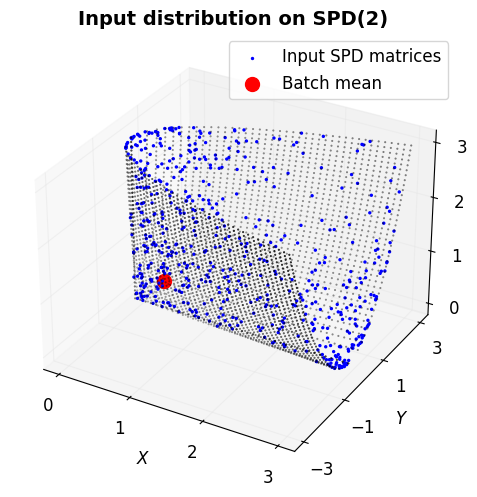

In [58]:
def plot_spd_panel(
    ax,
    matrices,
    boundary,
    mean,
    sample_label,
    mean_label,
    color,
    max_bound=3,
    font_size=12,
    sample_size=2,
    mean_size=100,
):
    boundary_X, boundary_Y, boundary_Z = boundary
    ax.scatter(boundary_X, boundary_Y, boundary_Z, s=1, c="black", marker=".")

    # Embed [[X, Y], [Y, Z]] as the point (X, Y, Z).
    values = matrices.detach().cpu().numpy()
    ax.scatter(
        values[:, 0, 0],
        values[:, 1, 0],
        values[:, 1, 1],
        s=sample_size,
        c=color,
        marker="o",
        label=sample_label,
        alpha=1,
    )

    mean = mean.detach().cpu()
    ax.scatter(
        mean[0, 0].item(),
        mean[1, 0].item(),
        mean[1, 1].item(),
        s=mean_size,
        color="red",
        marker="o",
        label=mean_label,
    )
    ax.legend(fontsize=font_size)
    ax.set_xlabel("$X$", fontsize=font_size)
    ax.set_ylabel("$Y$", fontsize=font_size)
    ax.set_zlabel("$Z$", fontsize=font_size)
    ax.set_xticks(np.arange(0, max_bound + 1, 1))
    ax.set_yticks(np.arange(-max_bound, max_bound + 1, 2))
    ax.set_zticks(np.arange(0, max_bound + 1, 1))
    ax.tick_params(axis="both", which="major", labelsize=font_size)

    grid_color = (0.9, 0.9, 0.9, 0.5)
    ax.xaxis._axinfo["grid"]["color"] = grid_color
    ax.yaxis._axinfo["grid"]["color"] = grid_color
    ax.zaxis._axinfo["grid"]["color"] = grid_color

# Use the AIM geometry to compute the mean shown in the input panel.
preview_liebn = LieBNSPD(
    shape=[2, 2],
    metric="AIM",
    karcher_steps=10,
).double()
input_spd_mean = preview_liebn.manifold.cal_geom_mean(spd_samples).detach()

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection="3d")
plot_spd_panel(
    ax,
    spd_samples,
    spd_boundary,
    input_spd_mean,
    "Input SPD matrices",
    "Batch mean",
    "b",
)
ax.set_title("Input distribution on SPD(2)", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()


### Apply LieBN-AIM

For batch mean $M$, variance $v^2$, scaling parameter $s$, bias $B$, and neutral element $E$, LieBN is computed as

$$
\begin{aligned}
\bar{P}_i
&=L_{M_{\odot}^{-1}}(P_i),\\[4pt]
\widehat{P}_i
&=\operatorname{Exp}_{E}\left(\frac{s}{\sqrt{v^2+\varepsilon}}\operatorname{Log}_{E}(\bar{P}_i)\right),\\[4pt]
\widetilde{P}_i
&=L_B(\widehat{P}_i).
\end{aligned}
$$

Here $B=E=I_2$.


In [59]:
liebn_aim_single = LieBNSPD(
    shape=[2, 2],
    metric="AIM",
    karcher_steps=10,
).double()

# A visualization needs only a forward pass, not gradient tracking.
with torch.no_grad():
    normalized_spd = liebn_aim_single(spd_samples).detach()

print(liebn_aim_single)
print("Scaling parameter:", liebn_aim_single.shift.item())


LieBNSPD(training=True, shape=[2, 2], momentum=0.1, batchdim=[0], eps=1e-05, is_detach=True, metric=AIM, power=1.0, alpha=1.0, beta=0.0, karcher_steps=10, running_mean=(2, 2), running_var=1.9428112402635875) 
 SPDAffineInvariantMetric(training=True, is_detach=True, n=2, dim=3, alpha=1.0, beta=0.0, karcher_steps=10, power=1.0, I=(2, 2))
Scaling parameter: 1.0


### Compare the input and normalized distributions


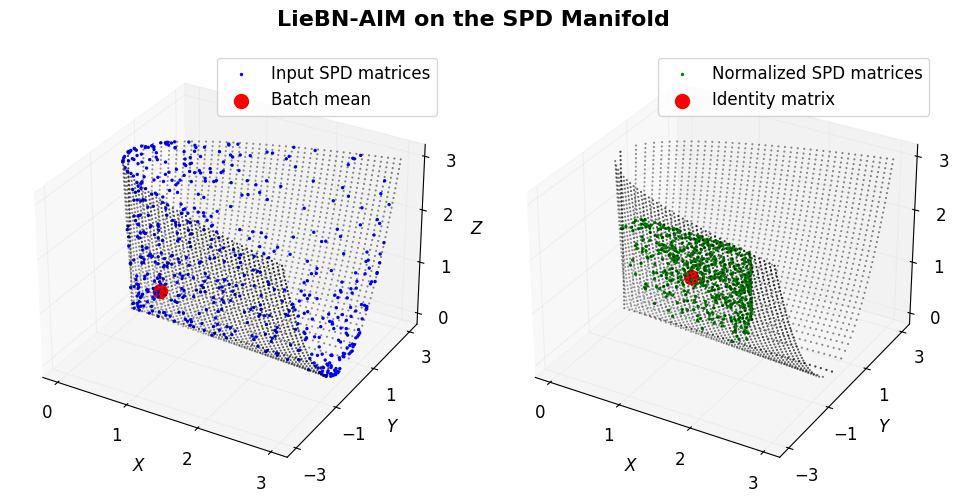

In [60]:
# Place the unchanged input and normalized output beside the same cone.
fig, axes = plt.subplots(
    1,
    2,
    subplot_kw={"projection": "3d"},
    figsize=(10, 5),
)

plot_spd_panel(
    axes[0],
    spd_samples,
    spd_boundary,
    input_spd_mean,
    "Input SPD matrices",
    "Batch mean",
    "b",
)
plot_spd_panel(
    axes[1],
    normalized_spd,
    spd_boundary,
    torch.eye(2, dtype=torch.float64),
    "Normalized SPD matrices",
    "Identity matrix",
    "g",
)

fig.suptitle(
    "LieBN-AIM on the SPD Manifold",
    fontsize=16,
    weight="bold",
)
plt.tight_layout()
plt.show()


**Interpret:** LieBN keeps every sample inside the SPD cone, moves the batch center to the identity, and normalizes dispersion under the affine-invariant geometry.


## Task 2 — Change the scaling parameter on $\operatorname{SPD}(2)$

The radial factor is

$$
t=\frac{s}{\sqrt{v^2+\varepsilon}}.
$$

Keep the input batch fixed and try $s=0.5$, $1.0$, and $1.5$.

**Predict:** How will the normalized cloud change?


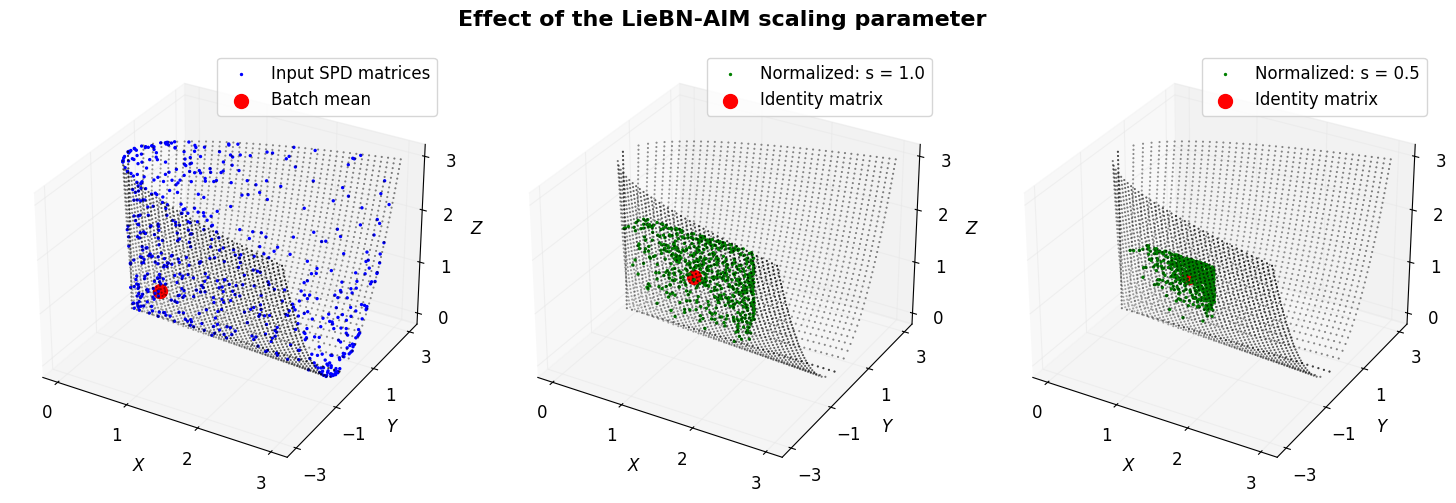

In [68]:
# Change only this value; the input batch and cone remain fixed.
spd_scaling_parameter = 0.5  # Try 0.5, 1.0, or 1.5

with torch.no_grad():
    liebn_aim_single.shift.fill_(spd_scaling_parameter)
    scaled_spd = liebn_aim_single(spd_samples).detach()

fig, axes = plt.subplots(
    1,
    3,
    subplot_kw={"projection": "3d"},
    figsize=(15, 5),
)

plot_spd_panel(
    axes[0], spd_samples, spd_boundary, input_spd_mean,
    "Input SPD matrices", "Batch mean", "b",
)
plot_spd_panel(
    axes[1], normalized_spd, spd_boundary,
    torch.eye(2, dtype=torch.float64),
    "Normalized: s = 1.0", "Identity matrix", "g",
)
plot_spd_panel(
    axes[2], scaled_spd, spd_boundary,
    torch.eye(2, dtype=torch.float64),
    f"Normalized: s = {spd_scaling_parameter}", "Identity matrix", "g",
)

fig.suptitle("Effect of the LieBN-AIM scaling parameter", fontsize=16, weight="bold")
plt.tight_layout()

scale_tag = str(spd_scaling_parameter).replace(".", "p")
fig.savefig(offline_dir / f"liebn_aim_scaling_{scale_tag}.png", dpi=300)
plt.show()


**Interpret:** The mean remains at $I_2$. Smaller $s$ contracts the output around $I_2$; larger $s$ expands it.


## Task 3 — LieBN across manifolds

In this task, we study how geometry changes LieBN. For SPD and correlation matrices, we compare different invariant metrics; for rotations, we compare left and right translations. We will observe how these choices affect the batch mean and the normalized distribution.

| Manifold | Definition&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | LieBN variants |
|:--|:--|:--|
| SPD | $\operatorname{SPD}(2)$ | AIM and CRIM |
| Rotation | $\operatorname{SO}(3)=\{R\in\operatorname{O}(3)\mid \det R=1\}$ | Left and Right |
| Correlation | $\operatorname{Cor}^{+}(3)=\{C\in\operatorname{SPD}(3)\mid\operatorname{diag}(C)=\mathbf{1}\}$ | ECM and LSM |

**SPD visualization.** As in Task 1, $\operatorname{SPD}(2)$ is plotted inside the cone $xz-y^2>0$.

**Rotation visualization.** $\operatorname{SO}(3)$ is represented by the axis–angle vector $\omega=\theta u$ inside the ball $\lVert\omega\rVert\leq\pi$. Antipodal boundary points represent the same rotation.

**Correlation visualization.** Write

$$
C(x,y,z)=\begin{pmatrix}1&x&y\\x&1&z\\y&z&1\end{pmatrix}.
$$

Using coordinates $(x,y,z)$, the elliptope boundary is $1+2xyz-x^2-y^2-z^2=0$.


### Generate the input batches and boundaries


In [62]:
# Sample the radius-pi boundary of the SO(3) axis-angle ball.
def generate_surface_dots(n=40):
    X, Y, _ = np.meshgrid(
        np.linspace(-np.pi, np.pi, n),
        np.linspace(-np.pi, np.pi, n),
        np.linspace(-np.pi, np.pi, n),
    )
    sphere_x = np.pi * np.sin(Y) * np.cos(X)
    sphere_y = np.pi * np.sin(Y) * np.sin(X)
    sphere_z = np.pi * np.cos(Y)
    return sphere_x.ravel(), sphere_y.ravel(), sphere_z.ravel()

# Normalize a covariance matrix to unit diagonal.
def covariance_to_correlation(covariance):
    variances = torch.diagonal(covariance, dim1=-2, dim2=-1)
    standard_deviations = torch.sqrt(variances)
    denominator = (
        standard_deviations.unsqueeze(-1)
        * standard_deviations.unsqueeze(-2)
    )
    return covariance / denominator

# Generate full-rank correlation matrices from random covariances.
def random_correlation(*shape, eps=1e-6):
    A = torch.randn(shape) * 1.5 - 1
    covariance = A @ A.transpose(-2, -1)
    covariance += eps * torch.eye(shape[-1])
    return covariance_to_correlation(covariance)

# Generate rank-deficient correlation matrices on the elliptope boundary.
def generate_correlation_boundary(num_matrices_per_case=200):
    boundary = []

    for _ in range(num_matrices_per_case):
        eigenvalues = np.abs(np.random.rand(3))
        eigenvalues[2] = 0
        permutations = np.unique(
            np.array(
                [
                    eigenvalues[[i, j, k]]
                    for i in range(3)
                    for j in range(3)
                    for k in range(3)
                    if i != j and j != k and i != k
                ]
            ),
            axis=0,
        )

        for values in permutations:
            Q, _ = np.linalg.qr(np.random.randn(3, 3))
            positive_semidefinite = Q @ np.diag(values) @ Q.T
            D = np.diag(
                1.0
                / np.sqrt(
                    np.diag(positive_semidefinite)
                    + np.finfo(float).eps
                )
            )
            correlation = D @ positive_semidefinite @ D
            boundary.append(
                [
                    correlation[1, 0],
                    correlation[2, 0],
                    correlation[2, 1],
                ]
            )

    return np.asarray(boundary).T

# Freeze one batch per manifold for every LieBN comparison.
set_seed(1024)
lie_n = 150
lie_spd = generate_random_spd2_matrices(
    lie_n * 4,
    max_bound=3,
).double()
lie_spd_boundary = generate_spd_boundary(num=40, max_bound=3)

rotation_manifold = RotMatrices()
lie_so3 = rotation_manifold.random(lie_n, 3, 3).double()
lie_so3_boundary = generate_surface_dots(n=40)

lie_correlation = random_correlation(lie_n * 2, 3, 3).double()
lie_correlation_boundary = generate_correlation_boundary(
    num_matrices_per_case=lie_n
)

print("SPD:", tuple(lie_spd.shape))
print("SO(3):", tuple(lie_so3.shape))
print("Correlation:", tuple(lie_correlation.shape))


SPD: (600, 2, 2)
SO(3): (150, 3, 3)
Correlation: (300, 3, 3)


### Define the $\operatorname{SO}(3)$ and correlation visualizations


In [63]:
# Represent each rotation by its axis-angle vector inside the radius-pi ball.
def plot_so3_panel(
    ax,
    rotations,
    surface_dots,
    mean,
    sample_label,
    mean_label,
    color,
    font_size=12,
    sample_size=2,
    mean_size=100,
):
    x, y, z = surface_dots
    ax.scatter(x, y, z, s=0.1, c="grey", marker=".")

    axis_angles = matrix_to_axis_angle(rotations)
    axes = axis_angles[:, :3]
    angles = torch.norm(axis_angles, dim=1)
    normalized_axes = axes / torch.norm(axes, dim=1, keepdim=True)
    points = normalized_axes * angles.unsqueeze(1)

    # Duplicate boundary points because antipodal vectors represent one pi rotation.
    pi_mask = torch.isclose(
        angles,
        torch.tensor(np.pi, dtype=angles.dtype),
        atol=1e-4,
    )
    pi_points = points[pi_mask].detach().cpu()
    ax.scatter(
        pi_points[:, 0],
        pi_points[:, 1],
        pi_points[:, 2],
        s=sample_size,
        c=color,
        marker=".",
        label=sample_label,
    )
    ax.scatter(
        -pi_points[:, 0],
        -pi_points[:, 1],
        -pi_points[:, 2],
        s=sample_size,
        c=color,
        marker=".",
    )

    remaining = points[~pi_mask].detach().cpu()
    ax.scatter(
        remaining[:, 0],
        remaining[:, 1],
        remaining[:, 2],
        s=sample_size,
        c=color,
        marker="o",
        alpha=1,
    )

    mean_axis_angle = matrix_to_axis_angle(mean.unsqueeze(0)).squeeze(0).cpu()
    ax.scatter(
        mean_axis_angle[0],
        mean_axis_angle[1],
        mean_axis_angle[2],
        s=mean_size,
        color="red",
        marker="o",
        label=mean_label,
    )
    ax.legend(fontsize=font_size)
    ax.set_xlabel("$X$", fontsize=font_size)
    ax.set_ylabel("$Y$", fontsize=font_size)
    ax.set_zlabel("$Z$", fontsize=font_size)
    ax.set_xlim([-np.pi, np.pi])
    ax.set_ylim([-np.pi, np.pi])
    ax.set_zlim([-np.pi, np.pi])
    ax.tick_params(axis="both", which="major", labelsize=font_size)

    grid_color = (0.9, 0.9, 0.9, 0.5)
    ax.xaxis._axinfo["grid"]["color"] = grid_color
    ax.yaxis._axinfo["grid"]["color"] = grid_color
    ax.zaxis._axinfo["grid"]["color"] = grid_color

# Plot the three free lower-triangular entries inside the elliptope.
def plot_correlation_panel(
    ax,
    matrices,
    boundary,
    mean,
    sample_label,
    mean_label,
    color,
    font_size=12,
    sample_size=2,
    mean_size=100,
):
    ax.scatter(
        boundary[0],
        boundary[1],
        boundary[2],
        s=1,
        c="black",
        marker=".",
    )

    values = matrices.detach().cpu().numpy()
    ax.scatter(
        values[:, 1, 0],
        values[:, 2, 0],
        values[:, 2, 1],
        s=sample_size,
        c=color,
        marker="o",
        label=sample_label,
        alpha=1,
    )

    mean = mean.detach().cpu()
    ax.scatter(
        mean[1, 0].item(),
        mean[2, 0].item(),
        mean[2, 1].item(),
        s=mean_size,
        color="red",
        marker="o",
        label=mean_label,
    )
    ax.legend(fontsize=font_size)
    ax.set_xlabel("$X$", fontsize=font_size)
    ax.set_ylabel("$Y$", fontsize=font_size)
    ax.set_zlabel("$Z$", fontsize=font_size)
    ax.set_xticks(np.arange(0, 2, 1))
    ax.set_yticks(np.arange(-1, 2, 2))
    ax.set_zticks(np.arange(0, 2, 1))
    ax.tick_params(axis="both", which="major", labelsize=font_size)

    grid_color = (0.9, 0.9, 0.9, 0.5)
    ax.xaxis._axinfo["grid"]["color"] = grid_color
    ax.yaxis._axinfo["grid"]["color"] = grid_color
    ax.zaxis._axinfo["grid"]["color"] = grid_color

def make_liebn_figure():
    return plt.subplots(
        3,
        4,
        subplot_kw={"projection": "3d"},
        figsize=(20, 11),
    )

def add_liebn_titles(fig):
    title_size = 16
    fig.text(
        0.25,
        0.96,
        "LieBN-AIM on the SPD Manifold",
        ha="center",
        fontsize=title_size,
        weight="bold",
    )
    fig.text(
        0.75,
        0.96,
        "LieBN-CRIM on the SPD Manifold",
        ha="center",
        fontsize=title_size,
        weight="bold",
    )
    fig.text(
        0.25,
        0.64,
        "LieBN-Left on the Rotation Matrix",
        ha="center",
        fontsize=title_size,
        weight="bold",
    )
    fig.text(
        0.75,
        0.64,
        "LieBN-Right on the Rotation Matrix",
        ha="center",
        fontsize=title_size,
        weight="bold",
    )
    fig.text(
        0.25,
        0.32,
        "LieBN-ECM on the Correlation Matrix",
        ha="center",
        fontsize=title_size,
        weight="bold",
    )
    fig.text(
        0.75,
        0.32,
        "LieBN-LSM on the Correlation Matrix",
        ha="center",
        fontsize=title_size,
        weight="bold",
    )


### Construct the six LieBN layers

Each batch mean is computed using the geometry of its corresponding layer.


In [64]:
liebn_aim = LieBNSPD(
    shape=[2, 2],
    metric="AIM",
    karcher_steps=10,
).double()
liebn_crim = LieBNSPD(
    shape=[2, 2],
    metric="CRIM",
    karcher_steps=10,
).double()
liebn_left = LieBNRot(
    shape=[3, 3],
    is_left=True,
    karcher_steps=10,
    batchdim=[0],
).double()
liebn_right = LieBNRot(
    shape=[3, 3],
    is_left=False,
    karcher_steps=10,
    batchdim=[0],
).double()
liebn_ecm = LieBNCor(
    shape=[3, 3],
    metric="ECM",
).double()
liebn_lsm = LieBNCor(
    shape=[3, 3],
    metric="LSM",
    alpha=0,
    param_1=1,
    param_2=1,
).double()

# Compute every input mean with the same geometry used by its BN layer.
with torch.no_grad():
    lie_input_means = {
        "AIM": liebn_aim.manifold.cal_geom_mean(lie_spd).detach(),
        "CRIM": liebn_crim.manifold.cal_geom_mean(lie_spd).detach(),
        "Left": liebn_left.manifold.cal_geom_mean(lie_so3).detach(),
        "Right": liebn_right.manifold.cal_geom_mean(lie_so3).detach(),
    }

    for name, layer in {"ECM": liebn_ecm, "LSM": liebn_lsm}.items():
        deformed = layer.manifold.deformation(lie_correlation)
        mean = layer.manifold.cal_geom_mean(deformed)
        lie_input_means[name] = layer.manifold.inv_deformation(mean).detach()


### Apply LieBN and draw the overview

All scaling parameters are set to $s=1$, and each bias remains at the neutral element.


In [69]:
# Apply one common scale to all LieBN variants.
liebn_scaling_parameter = 1.0

with torch.no_grad():
    liebn_aim.shift.fill_(liebn_scaling_parameter)
    liebn_crim.shift.fill_(liebn_scaling_parameter)
    liebn_left.shift.fill_(liebn_scaling_parameter)
    liebn_right.shift.fill_(liebn_scaling_parameter)
    liebn_ecm.shift.fill_(liebn_scaling_parameter)
    liebn_lsm.shift.fill_(liebn_scaling_parameter)

    lie_outputs = {
        "AIM": liebn_aim(lie_spd).detach(),
        "CRIM": liebn_crim(lie_spd).detach(),
        "Left": liebn_left(lie_so3).detach(),
        "Right": liebn_right(lie_so3).detach(),
        "ECM": liebn_ecm(lie_correlation).detach(),
        "LSM": liebn_lsm(lie_correlation).detach(),
    }


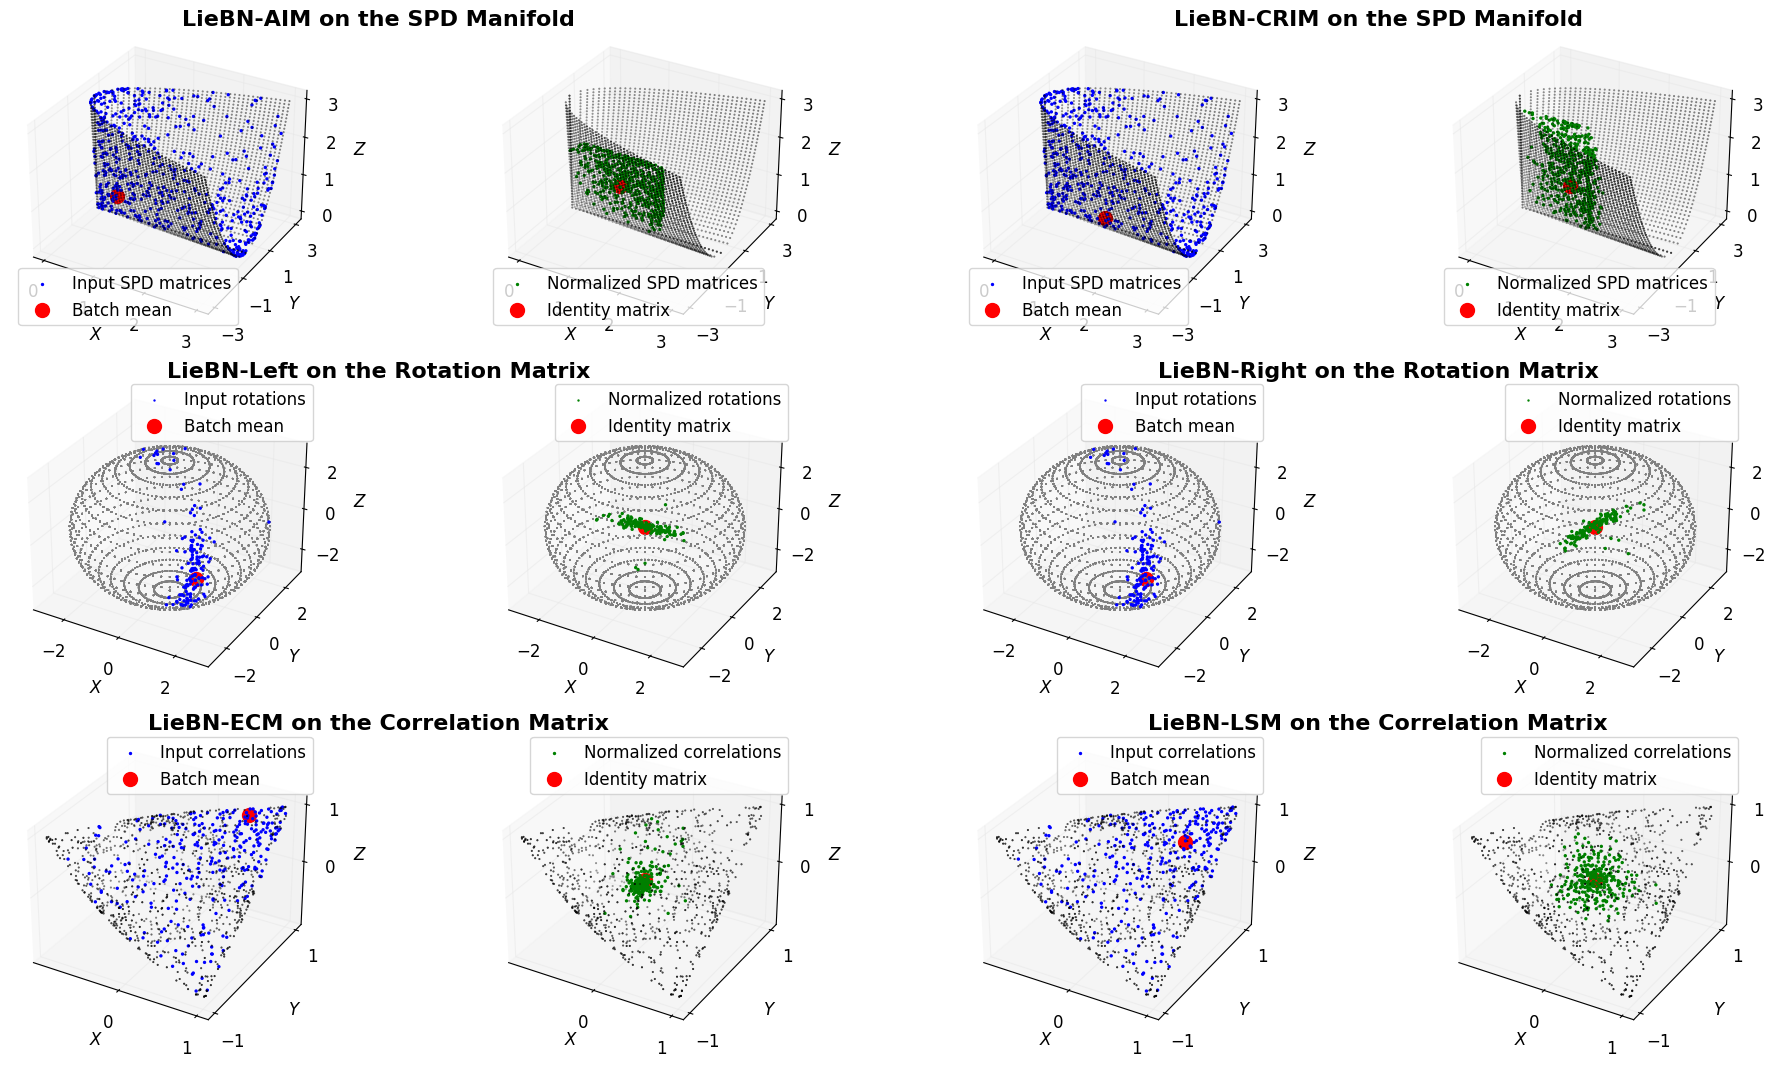

In [70]:
def draw_liebn_figure(outputs, save_path=None):
    fig, axes = make_liebn_figure()

    plot_spd_panel(
        axes[0, 0], lie_spd, lie_spd_boundary, lie_input_means["AIM"],
        "Input SPD matrices", "Batch mean", "b",
    )
    plot_spd_panel(
        axes[0, 1], outputs["AIM"], lie_spd_boundary,
        torch.eye(2, dtype=torch.float64),
        "Normalized SPD matrices", "Identity matrix", "g",
    )
    plot_spd_panel(
        axes[0, 2], lie_spd, lie_spd_boundary, lie_input_means["CRIM"],
        "Input SPD matrices", "Batch mean", "b",
    )
    plot_spd_panel(
        axes[0, 3], outputs["CRIM"], lie_spd_boundary,
        torch.eye(2, dtype=torch.float64),
        "Normalized SPD matrices", "Identity matrix", "g",
    )

    plot_so3_panel(
        axes[1, 0], lie_so3, lie_so3_boundary, lie_input_means["Left"],
        "Input rotations", "Batch mean", "b",
    )
    plot_so3_panel(
        axes[1, 1], outputs["Left"], lie_so3_boundary,
        torch.eye(3, dtype=torch.float64),
        "Normalized rotations", "Identity matrix", "g",
    )
    plot_so3_panel(
        axes[1, 2], lie_so3, lie_so3_boundary, lie_input_means["Right"],
        "Input rotations", "Batch mean", "b",
    )
    plot_so3_panel(
        axes[1, 3], outputs["Right"], lie_so3_boundary,
        torch.eye(3, dtype=torch.float64),
        "Normalized rotations", "Identity matrix", "g",
    )

    plot_correlation_panel(
        axes[2, 0], lie_correlation, lie_correlation_boundary,
        lie_input_means["ECM"], "Input correlations", "Batch mean", "b",
    )
    plot_correlation_panel(
        axes[2, 1], outputs["ECM"], lie_correlation_boundary,
        torch.eye(3, dtype=torch.float64),
        "Normalized correlations", "Identity matrix", "g",
    )
    plot_correlation_panel(
        axes[2, 2], lie_correlation, lie_correlation_boundary,
        lie_input_means["LSM"], "Input correlations", "Batch mean", "b",
    )
    plot_correlation_panel(
        axes[2, 3], outputs["LSM"], lie_correlation_boundary,
        torch.eye(3, dtype=torch.float64),
        "Normalized correlations", "Identity matrix", "g",
    )

    add_liebn_titles(fig)
    plt.tight_layout(pad=3)
    if save_path is not None:
        fig.savefig(save_path, dpi=300)
    plt.show()
    return fig

draw_liebn_figure(
    lie_outputs,
    offline_dir / "liebn_all_manifolds.png",
);


**Interpret — the role of geometry:**

1. **The metric changes the batch statistics.** AIM and CRIM assign different Fréchet means and variances to the same SPD batch; ECM and LSM do the same for the same correlation batch. Their normalized distributions are therefore different.
2. **The translation side changes rotation normalization.** LieBN-Left uses $\bar{R}_i=M^{-1}R_i$ for centering and $\widetilde{R}_i=B\widehat{R}_i$ for biasing, whereas LieBN-Right uses $\bar{R}_i=R_iM^{-1}$ and $\widetilde{R}_i=\widehat{R}_iB$. The output distributions differ because rotation multiplication is noncommutative.


## Takeaways

- LieBN maps manifold-valued inputs to normalized outputs that remain on the same manifold.
- Invariant metrics make group translations isometries.
- Centering moves the batch mean to the neutral element.
- The scaling parameter controls output dispersion.
- Different geometries produce different batch statistics and normalized distributions.
